In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/arnobbhowmik/ton-iot-network-dataset/train_test_network.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, Dropout, BatchNormalization, Activation
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

2026-04-10 19:40:20.689449: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775850020.904657      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775850020.967537      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775850021.489467      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775850021.489511      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775850021.489513      23 computation_placer.cc:177] computation placer alr

In [3]:
df = pd.read_csv('/kaggle/input/datasets/arnobbhowmik/ton-iot-network-dataset/train_test_network.csv')

df = df.drop_duplicates()

leakage_cols = ['src_ip', 'dst_ip', 'src_port', 'dst_port', 'label']
columns_to_drop = [col for col in leakage_cols if col in df.columns]

X = df.drop(columns=columns_to_drop)

le_type = LabelEncoder()
y = le_type.fit_transform(X['type'])
X = X.drop(columns=['type'])

categorical_cols = X.select_dtypes(include=['object']).columns

for col in categorical_cols:
    X[col] = X[col].fillna('None').astype(str)

X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
X[numeric_cols] = X[numeric_cols].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = X_scaled.astype(np.float32)

In [4]:
X_train_full, X_test_full, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [5]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_full, y_train)

X_train_final = np.expand_dims(X_train_resampled, axis=2)
X_test_final = np.expand_dims(X_test_full, axis=2)
y_train_final = y_train_resampled

num_classes = len(np.unique(y))

In [6]:
model = Sequential([
    Conv1D(filters=64, kernel_size=3, input_shape=(X_train_final.shape[1], 1)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling1D(pool_size=2),
    
    Conv1D(filters=32, kernel_size=3),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling1D(pool_size=2),
    
    Flatten(),
    Dense(64),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),
    
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_ids_model_multi.keras', monitor='val_loss', save_best_only=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=0.00001)

history = model.fit(
    X_train_final, y_train_final,
    epochs=50,
    batch_size=256,
    validation_data=(X_test_final, y_test),
    callbacks=[early_stop, checkpoint, reduce_lr]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1775850100.174476      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775850100.180746      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/50


I0000 00:00:1775850106.764984      72 service.cc:152] XLA service 0x7d055c010160 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775850106.765024      72 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775850106.765028      72 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775850107.251755      72 cuda_dnn.cc:529] Loaded cuDNN version 91002


  11/1315 ━━━━━━━━━━━━━━━━━━━━ 22s 17ms/step - accuracy: 0.2666 - loss: 2.2817

I0000 00:00:1775850110.873306      72 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1315/1315 ━━━━━━━━━━━━━━━━━━━━ 29s 18ms/step - accuracy: 0.6826 - loss: 0.9204 - val_accuracy: 0.4143 - val_loss: 1.8216 - learning_rate: 0.0010
Epoch 2/50
1315/1315 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.7918 - loss: 0.5764 - val_accuracy: 0.3911 - val_loss: 3.3030 - learning_rate: 0.0010
Epoch 3/50
1315/1315 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.8204 - loss: 0.5059 - val_accuracy: 0.2205 - val_loss: 26.8555 - learning_rate: 0.0010
Epoch 4/50
1315/1315 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.8328 - loss: 0.4688 - val_accuracy: 0.4794 - val_loss: 4.8640 - learning_rate: 5.0000e-04
Epoch 5/50
1315/1315 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.8461 - loss: 0.4391 - val_accuracy: 0.3075 - val_loss: 38.2404 - learning_rate: 5.0000e-04
Epoch 6/50
1315/1315 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.8665 - loss: 0.3953 - val_accuracy: 0.4039 - val_loss: 4.8337 - learning_rate: 2.5000e-04


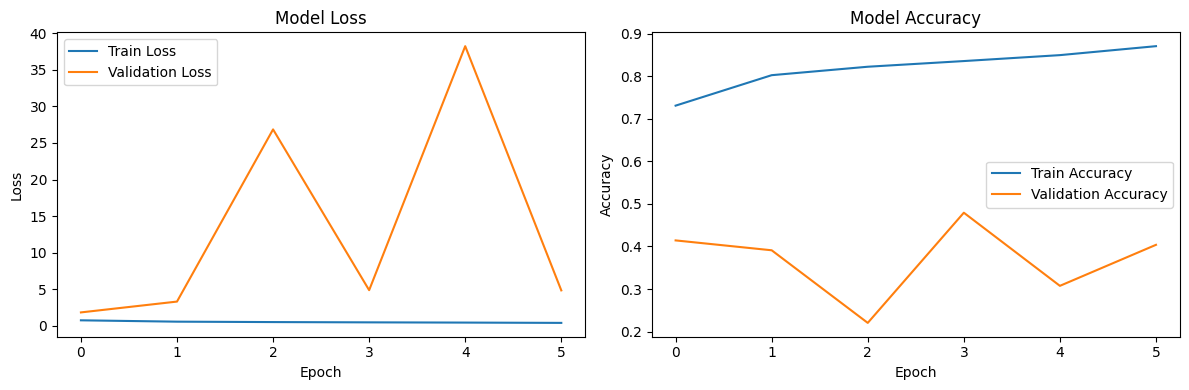

1191/1191 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

    backdoor       0.00      0.00      0.00      3714
        ddos       0.98      0.27      0.43      3993
         dos       0.31      0.89      0.46      3756
   injection       0.37      0.95      0.53      4078
        mitm       0.08      0.90      0.15       210
      normal       1.00      0.31      0.47      8389
    password       1.00      0.05      0.10      3948
  ransomware       0.97      0.58      0.73      2944
    scanning       0.12      0.00      0.00      4072
         xss       0.31      0.92      0.46      2991

    accuracy                           0.41     38095
   macro avg       0.51      0.49      0.33     38095
weighted avg       0.61      0.41      0.36     38095



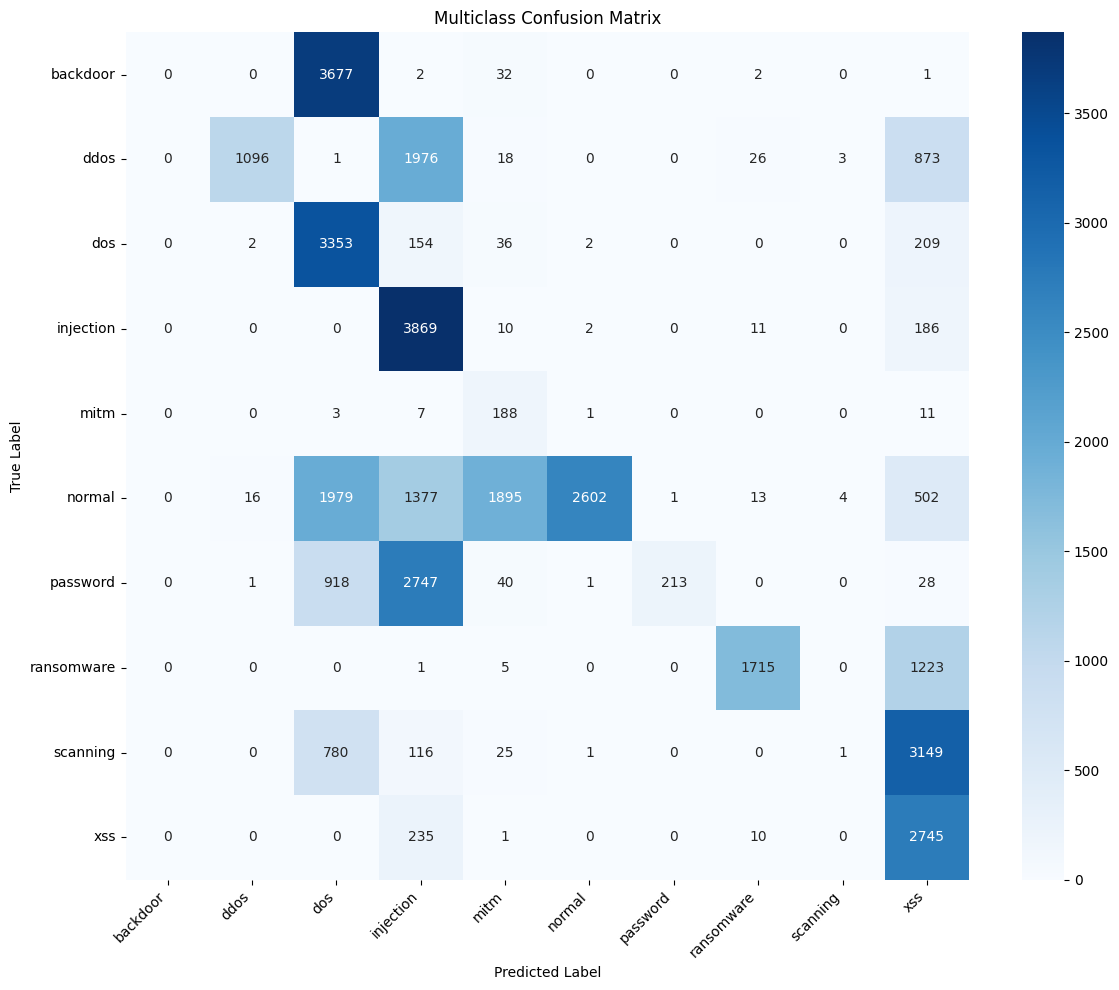

In [7]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

y_pred_probs = model.predict(X_test_final)
y_pred = np.argmax(y_pred_probs, axis=1)

target_names = le_type.classes_

print(classification_report(y_test, y_pred, target_names=target_names))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Multiclass Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()